In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from copy import deepcopy as copy
import importlib
import phise

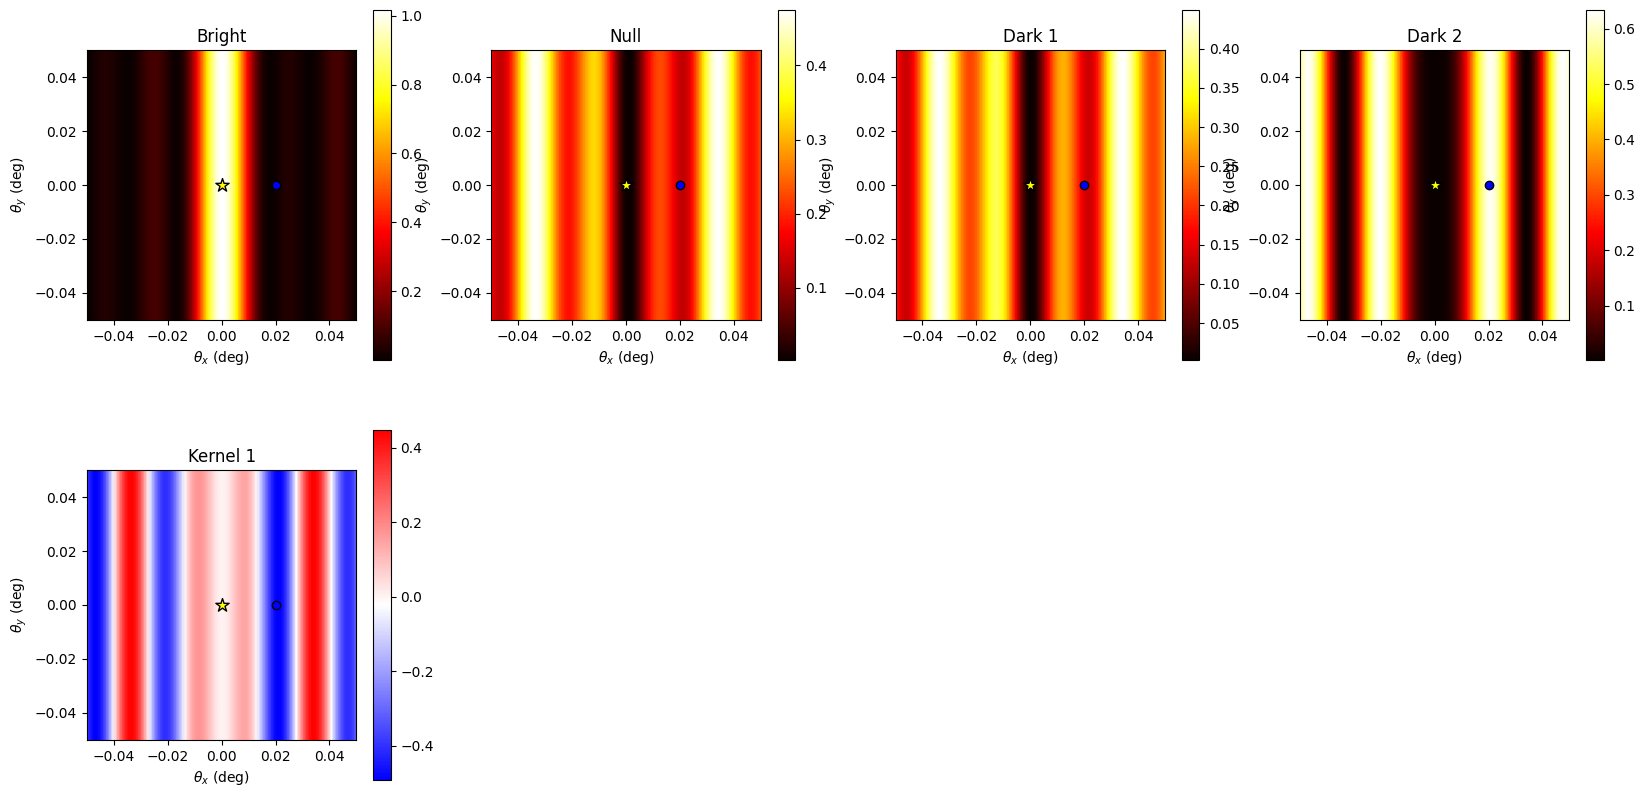


Tunable Laser Star throughputs:
----------
   Bright: 101.84%,   Null: 0.67%,   Dark 1: 0.22%,   Dark 2: 0.25%
   Kernel 1: -0.03%
Unnamed Companion throughputs:
----------
   Bright: 0.96%,   Null: 13.70%,   Dark 1: 14.26%,   Dark 2: 62.23%
   Kernel 1: -47.97%


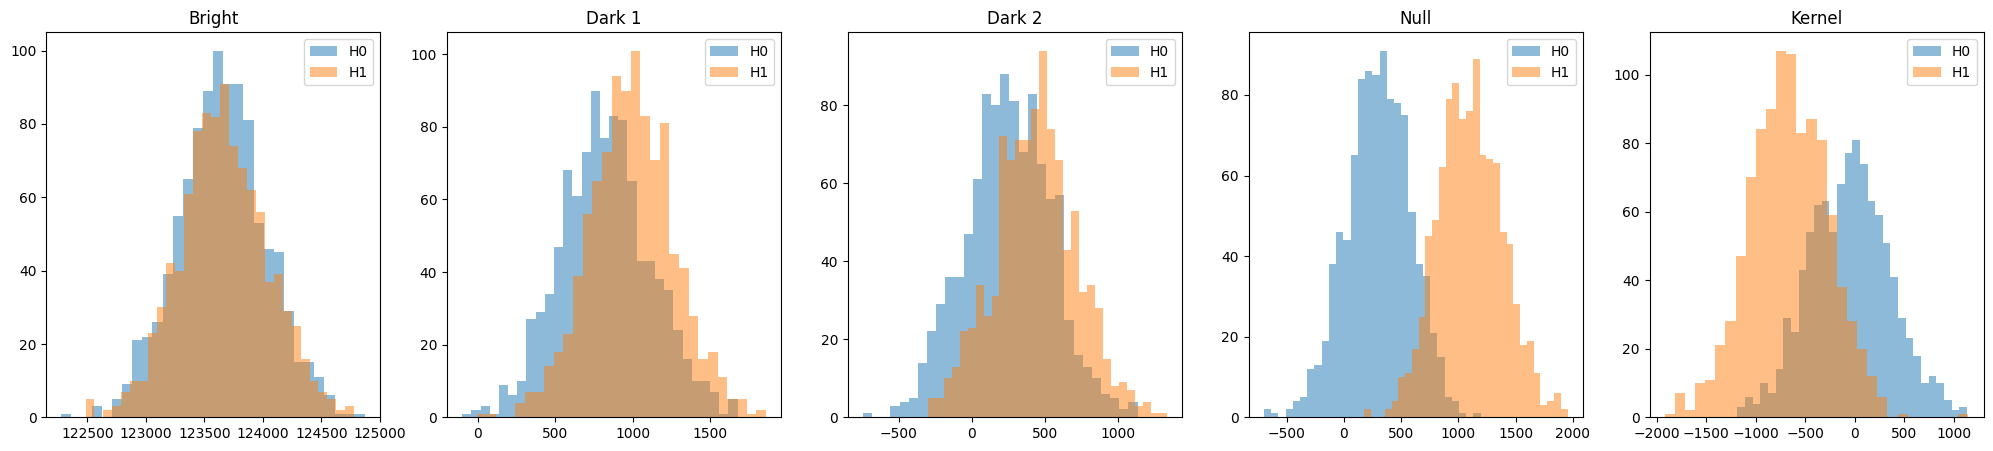

In [25]:
importlib.reload(phise)

ctx = phise.examples.contexts.get_PHOB()
ctx.interferometer.fov = 0.1 * u.deg
ctx.chip.calibrate()
ctx.Γ = 0 * u.nm # 1nm of upstream piston rms
ctx_h0 = copy(ctx)
ctx_h0.target.companions = []
ctx_h1 = copy(ctx)
ctx_h1.target.companions = [phise.Companion(1e-2, 0.02*u.deg, 0*u.deg)]

ctx_h1.plot_transmission_maps(N=100)

N = 1000

n_raw = ctx.chip.nb_raw_outputs
n_processed = ctx.chip.nb_processed_outputs

data_h0 = np.empty((n_raw + n_processed, N))
data_h1 = np.empty((n_raw + n_processed, N))

for i in range(N):
    h0_outs = ctx_h0.observe()
    h1_outs = ctx_h1.observe()
    data_h0[:n_raw, i] = h0_outs
    data_h1[:n_raw, i] = h1_outs
    data_h0[n_raw:, i] = ctx_h0.chip.process_outputs(h0_outs)
    data_h1[n_raw:, i] = ctx_h1.chip.process_outputs(h1_outs)

titles = ['Bright', 'Dark 1', 'Dark 2', 'Null', 'Kernel']
fig, axs = plt.subplots(1, n_raw + n_processed, figsize=((n_raw + n_processed) * 5, 5))
for i in range(n_raw + n_processed):
    axs[i].hist(data_h0[i, :], bins=30, alpha=0.5, label='H0')
    axs[i].hist(data_h1[i, :], bins=30, alpha=0.5, label='H1')
    axs[i].set_title(titles[i])
    axs[i].legend()